In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [3]:
task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]

ref = 'bipolar'

hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'

dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 2254/2254 [00:16<00:00, 133.00it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 472320
PIC electrode count: 417344


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [6]:
spatial = HGAs[
    (HGAs['phase'] == 'delay') &
    (HGAs['description'] == 'Repeat') &
    (HGAs['roi'].isin(['AIC','MFG','dACC'])) &
    (HGAs['time'] >= 0) &
    (HGAs['time'] <= 1) &
    (HGAs['mask'] == True)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0007_RFG1-2,0.455224,57.291674,20.558277,-14.696772,AIC,ctx_rh_G_insular_short,delay,R,D0007,Repeat,SentenceRep
1,D0007_RFG33-34,0.565952,50.361938,22.050593,40.166487,MFG,ctx_rh_G_front_middle,delay,R,D0007,Repeat,SentenceRep
2,D0008_LD9-10,0.423120,-39.605005,51.304111,11.277045,MFG,ctx_lh_G_front_middle,delay,L,D0008,Repeat,SentenceRep
3,D0008_RE2-3,0.312465,3.723868,17.197831,34.279996,dACC,ctx_rh_G_and_S_cingul-Mid-Ant,delay,R,D0008,Repeat,SentenceRep
4,D0009_RMMF1-3,0.037354,9.541717,20.017485,21.852251,dACC,ctx_rh_G_and_S_cingul-Mid-Ant,delay,R,D0009,Repeat,SentenceRep


2026-04-07 10:12:08.776 (  74.660s) [    7F1A118E8740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


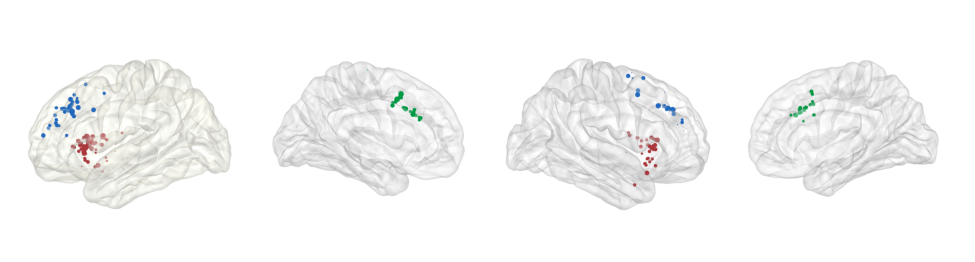

In [7]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# ROI colors
roi_colors = {
    'AIC': red,
    'MFG': blue, 
    'dACC': green
}

# Load pial surfaces
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

# Size mapping based on HGA
vmin, vmax = np.percentile(spatial['HGA'].values, 2), np.percentile(spatial['HGA'].values, 98)
size_min, size_max = 5, 35

def weight_to_size(weight, vmin, vmax, size_min, size_max):
    normalized = np.clip((weight - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes(brain, coords, hga_vals, roi_vals, color_dict):
    for i in range(len(coords)):
        pt = coords[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        color = color_dict[roi]
        size = weight_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(32*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1, 1, 1]})
plt.subplots_adjust(wspace=-0.1)

# Left lateral - AIC and MFG
lh_lateral = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.95, 0.95, 0.9), alpha=0.3, size=(600*cm, 600*cm)
)
lh_lateral._renderer.plotter.window_size = [1400, 1400]

lh_lateral_data = spatial[(spatial['hemi'] == 'L') & (spatial['roi'].isin(['AIC', 'MFG']))]
if len(lh_lateral_data) > 0:
    coords = lh_lateral_data[['x', 'y', 'z']].values
    _, indices = lh_tree.query(coords)
    coords_on_pial = lh_coords_pial[indices]
    add_electrodes(lh_lateral, coords_on_pial, lh_lateral_data['HGA'].values,
                  lh_lateral_data['roi'].values, roi_colors)

lh_lateral.show_view(view="lateral", distance=400)
axes[0].imshow(lh_lateral.screenshot(mode="rgb"))
axes[0].axis("off")
lh_lateral.close()

# Left medial - dACC only
lh_medial = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.3, size=(600*cm, 600*cm)
)
lh_medial._renderer.plotter.window_size = [1400, 1400]

lh_dacc = spatial[(spatial['hemi'] == 'L') & (spatial['roi'] == 'dACC')]
if len(lh_dacc) > 0:
    coords = lh_dacc[['x', 'y', 'z']].values
    _, indices = lh_tree.query(coords)
    coords_on_pial = lh_coords_pial[indices]
    add_electrodes(lh_medial, coords_on_pial, lh_dacc['HGA'].values,
                  lh_dacc['roi'].values, roi_colors)

lh_medial.show_view(view="medial", distance=400)
axes[1].imshow(lh_medial.screenshot(mode="rgb"))
axes[1].axis("off")
lh_medial.close()

# Right lateral - AIC and MFG
rh_lateral = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.3, size=(600*cm, 600*cm)
)
rh_lateral._renderer.plotter.window_size = [1400, 1400]

rh_lateral_data = spatial[(spatial['hemi'] == 'R') & (spatial['roi'].isin(['AIC', 'MFG']))]
if len(rh_lateral_data) > 0:
    coords = rh_lateral_data[['x', 'y', 'z']].values
    _, indices = rh_tree.query(coords)
    coords_on_pial = rh_coords_pial[indices]
    add_electrodes(rh_lateral, coords_on_pial, rh_lateral_data['HGA'].values,
                  rh_lateral_data['roi'].values, roi_colors)

rh_lateral.show_view(view="lateral", distance=400)
axes[2].imshow(rh_lateral.screenshot(mode="rgb"))
axes[2].axis("off")
rh_lateral.close()

# Right medial - dACC only
rh_medial = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.3, size=(600*cm, 600*cm)
)
rh_medial._renderer.plotter.window_size = [1400, 1400]

rh_dacc = spatial[(spatial['hemi'] == 'R') & (spatial['roi'] == 'dACC')]
if len(rh_dacc) > 0:
    coords = rh_dacc[['x', 'y', 'z']].values
    _, indices = rh_tree.query(coords)
    coords_on_pial = rh_coords_pial[indices]
    add_electrodes(rh_medial, coords_on_pial, rh_dacc['HGA'].values,
                  rh_dacc['roi'].values, roi_colors)

rh_medial.show_view(view="medial", distance=400)
axes[3].imshow(rh_medial.screenshot(mode="rgb"))
axes[3].axis("off")
rh_medial.close()

plt.show()


处理 lh lateral:
  AIC: 54 电极, 15403 个顶点, 密度 [0.000, 9.062]
  MFG: 34 电极, 13519 个顶点, 密度 [0.038, 4.390]

处理 lh medial:
  dACC: 21 电极, 7217 个顶点, 密度 [0.122, 2.813]

处理 rh lateral:
  AIC: 30 电极, 12923 个顶点, 密度 [0.001, 3.935]
  MFG: 23 电极, 12983 个顶点, 密度 [0.000, 2.645]

处理 rh medial:
  dACC: 19 电极, 8131 个顶点, 密度 [0.040, 2.610]

全局密度范围（所有ROI）: [0.0000, 9.0621]
  MFG顶点: 13019
  AIC顶点: 14072
  dACC顶点: 0
  MFG顶点: 0
  AIC顶点: 0
  dACC顶点: 7217
  MFG顶点: 11519
  AIC顶点: 12473
  dACC顶点: 0
  MFG顶点: 0
  AIC顶点: 0
  dACC顶点: 8131


/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


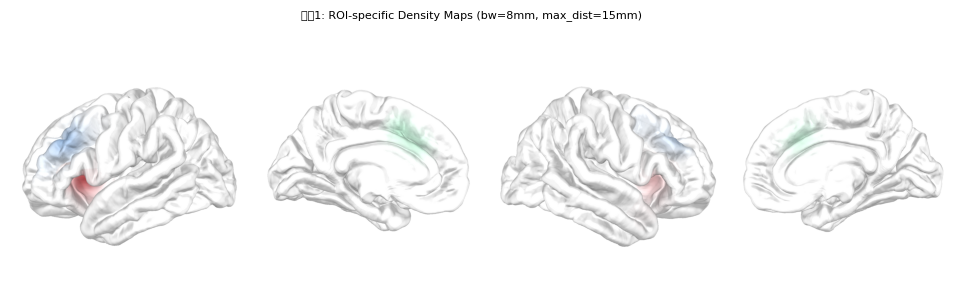


版本1完成！
AIC=红色, MFG=蓝色, dACC=绿色
每个顶点显示密度最强的ROI颜色


In [8]:
# 版本1：不同ROI使用不同颜色的密度图（每个顶点显示最强ROI的颜色）
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
from mne.viz import Brain
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

def compute_roi_density_with_mask(surface_coords, electrode_coords, hga_values, roi_labels, bandwidth=15, max_distance=30):
    """
    为每个ROI分别计算密度图
    """
    unique_rois = np.unique(roi_labels)
    density_by_roi = {}
    mask_by_roi = {}
    
    for roi in unique_rois:
        roi_mask = roi_labels == roi
        roi_coords = electrode_coords[roi_mask]
        roi_hga = hga_values[roi_mask]
        
        if len(roi_coords) > 0:
            distances = cdist(surface_coords, roi_coords)
            min_distances = distances.min(axis=1)
            mask = min_distances < max_distance
            
            kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
            density = np.dot(kernel_values, roi_hga)
            density[~mask] = 0
            
            density_by_roi[roi] = density
            mask_by_roi[roi] = mask
            
            valid_vals = density[mask & (density > 0)]
            if len(valid_vals) > 0:
                print(f"  {roi}: {len(roi_coords)} 电极, {mask.sum()} 个顶点, 密度 [{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density_by_roi, mask_by_roi

# 创建图形
fig, axes = plt.subplots(1, 4, figsize=(32*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1, 1, 1]})
plt.subplots_adjust(wspace=-0.1)

# 参数设置
bandwidth = 8
max_distance = 15
alpha = 0.95
cortex_color = (0.95, 0.95, 0.95)
cortex_alpha = 0.1

# ROI颜色（RGB）
roi_colors = {
    'MFG': blue,
    'AIC': red,
    'dACC': green
}

# 视图配置
view_configs = [
    ('lh', 'lateral', lh_coords_pial, spatial[(spatial['hemi'] == 'L') & (spatial['roi'].isin(['AIC', 'MFG']))]),
    ('lh', 'medial', lh_coords_pial, spatial[(spatial['hemi'] == 'L') & (spatial['roi'] == 'dACC')]),
    ('rh', 'lateral', rh_coords_pial, spatial[(spatial['hemi'] == 'R') & (spatial['roi'].isin(['AIC', 'MFG']))]),
    ('rh', 'medial', rh_coords_pial, spatial[(spatial['hemi'] == 'R') & (spatial['roi'] == 'dACC')]),
]

# ========== 第一遍：计算所有ROI的密度，确定全局范围 ==========
all_roi_densities = []
all_global_values = []

for idx, (hemi, view, surf_coords, df_sub) in enumerate(view_configs):
    print(f"\n处理 {hemi} {view}:")
    
    if len(df_sub) > 0:
        electrode_coords = df_sub[['x', 'y', 'z']].values
        hga_values = df_sub['HGA'].values
        roi_labels = df_sub['roi'].values
        
        density_by_roi, mask_by_roi = compute_roi_density_with_mask(
            surf_coords, electrode_coords, hga_values, roi_labels,
            bandwidth=bandwidth, max_distance=max_distance
        )
        
        all_roi_densities.append((density_by_roi, mask_by_roi))
        
        # 收集所有ROI的密度值用于全局归一化
        for roi, density in density_by_roi.items():
            mask = mask_by_roi[roi]
            valid_vals = density[mask & (density > 0)]
            if len(valid_vals) > 0:
                all_global_values.extend(valid_vals)
    else:
        all_roi_densities.append(None)

# 计算全局密度范围
if len(all_global_values) > 0:
    global_vmin = np.min(all_global_values)
    global_vmax = np.max(all_global_values)
    print(f"\n全局密度范围（所有ROI）: [{global_vmin:.4f}, {global_vmax:.4f}]")
else:
    global_vmin = 0
    global_vmax = 1

# ========== 第二遍：为每个视图绘制，使用自定义colormap ==========
for idx, (hemi, view, surf_coords, df_sub) in enumerate(view_configs):
    ax = axes[idx]
    
    brain = Brain(
        'fsaverage', subjects_dir=recon_dir, surf='pial', hemi=hemi,
        background='white', show=False, cortex=cortex_color, alpha=cortex_alpha, size=(600*cm, 600*cm)
    )
    brain._renderer.plotter.window_size = [1400, 1400]
    brain._renderer.plotter.set_background('white')

    if all_roi_densities[idx] is not None:
        density_by_roi, mask_by_roi = all_roi_densities[idx]
        n_vertices = len(surf_coords)
        
        # 创建一个组合的标量场和ROI标签场
        # 对于每个顶点，找出哪个ROI的密度最强
        combined_density = np.zeros(n_vertices)
        roi_assignment = np.zeros(n_vertices, dtype=int)  # 0=无ROI, 1=MFG, 2=AIC, 3=dACC
        
        roi_to_idx = {'MFG': 1, 'AIC': 2, 'dACC': 3}
        
        for roi, density in density_by_roi.items():
            mask = mask_by_roi[roi]
            # 对于每个有密度的顶点，如果当前ROI的密度更强，则更新
            update_mask = (density > combined_density) & mask & (density > 0)
            combined_density[update_mask] = density[update_mask]
            roi_assignment[update_mask] = roi_to_idx[roi]
        
        # 创建一个自定义的colormap，为每个ROI分配不同的颜色
        # 我们将使用一个技巧：将ROI索引编码到数据中
        # 数据格式：roi_idx * 1000 + normalized_density
        data_to_plot = np.zeros(n_vertices)
        for v_idx in range(n_vertices):
            if roi_assignment[v_idx] > 0:
                # 归一化密度
                norm_density = (combined_density[v_idx] - global_vmin) / (global_vmax - global_vmin)
                norm_density = np.clip(norm_density, 0, 1)
                # 编码：ROI索引 * 1000 + 密度值(0-999)
                data_to_plot[v_idx] = roi_assignment[v_idx] * 1000 + norm_density * 999
        
        # 创建自定义colormap
        # 为每个ROI创建从白色到基础颜色的渐变
        n_colors_per_roi = 1000
        colors_list = []
        
        # 0-999: 无数据（白色）
        colors_list.extend([[1, 1, 1, 1]] * n_colors_per_roi)
        
        # 1000-1999: MFG (蓝色)
        mfg_color = np.array(mcolors.to_rgb(roi_colors['MFG']))
        for i in range(n_colors_per_roi):
            intensity = i / (n_colors_per_roi - 1)
            color = (1 - intensity) * np.array([1, 1, 1]) + intensity * mfg_color
            colors_list.append(list(color) + [alpha])
        
        # 2000-2999: AIC (红色)
        aic_color = np.array(mcolors.to_rgb(roi_colors['AIC']))
        for i in range(n_colors_per_roi):
            intensity = i / (n_colors_per_roi - 1)
            color = (1 - intensity) * np.array([1, 1, 1]) + intensity * aic_color
            colors_list.append(list(color) + [alpha])
        
        # 3000-3999: dACC (绿色)
        dacc_color = np.array(mcolors.to_rgb(roi_colors['dACC']))
        for i in range(n_colors_per_roi):
            intensity = i / (n_colors_per_roi - 1)
            color = (1 - intensity) * np.array([1, 1, 1]) + intensity * dacc_color
            colors_list.append(list(color) + [alpha])
        
        custom_cmap = ListedColormap(colors_list)
        
        # 添加数据 - 使用fmin和fmax而不是vmin和vmax
        brain.add_data(
            data_to_plot,
            hemi=hemi,
            colormap=custom_cmap,
            alpha=alpha,
            colorbar=False,
            fmin=0,
            fmax=4000
        )
        
        print(f"  MFG顶点: {(roi_assignment == 1).sum()}")
        print(f"  AIC顶点: {(roi_assignment == 2).sum()}")
        print(f"  dACC顶点: {(roi_assignment == 3).sum()}")
    
    brain.show_view(view=view, distance=380)
    ax.imshow(brain.screenshot(mode='rgb'))
    ax.axis('off')
    brain.close()

plt.suptitle(f'版本1: ROI-specific Density Maps (bw={bandwidth}mm, max_dist={max_distance}mm)', fontsize=8)
plt.show()

print(f"\n版本1完成！")
print(f"AIC=红色, MFG=蓝色, dACC=绿色")
print(f"每个顶点显示密度最强的ROI颜色")


处理 lh lateral:
  AIC: 54电极, 15403顶点, 密度[0.000, 9.062]
  MFG: 34电极, 13519顶点, 密度[0.038, 4.390]

处理 lh medial:
  dACC: 21电极, 7217顶点, 密度[0.122, 2.813]

处理 rh lateral:
  AIC: 30电极, 12923顶点, 密度[0.001, 3.935]
  MFG: 23电极, 12983顶点, 密度[0.000, 2.645]

处理 rh medial:
  dACC: 19电极, 8131顶点, 密度[0.040, 2.610]

全局密度范围: [0.0402, 2.6102]
  密度层: MFG=13019, AIC=14072, dACC=0顶点
  电极层: 88个电极
  密度层: MFG=0, AIC=0, dACC=7217顶点
  电极层: 21个电极
  密度层: MFG=11519, AIC=12473, dACC=0顶点
  电极层: 53个电极
  密度层: MFG=0, AIC=0, dACC=8131顶点
  电极层: 19个电极


/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/IPytho

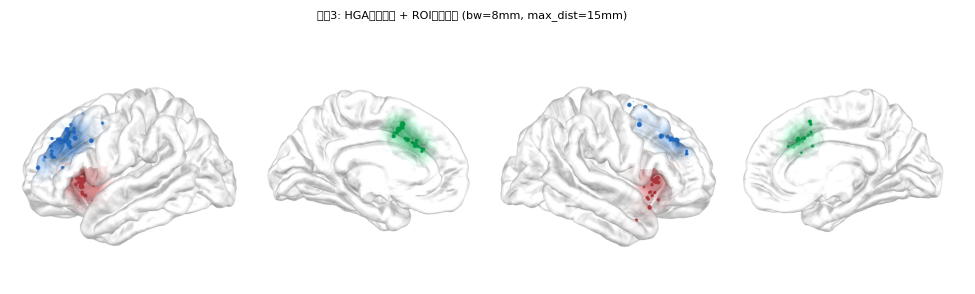


✓ 版本3完成！
说明：背景=HGA加权密度晕染（AIC=红, MFG=蓝, dACC=绿）
     前景=电极点（颜色=ROI，大小=HGA强度）


In [9]:
# ============================================================================
# 版本3：HGA加权密度晕染 + ROI颜色电极点叠加
# ============================================================================
# 功能：
# 1. 背景层：显示HGA加权密度的彩色晕染（每个ROI不同颜色）
# 2. 前景层：叠加电极点，电极使用各自ROI的颜色，大小反映HGA值
# 3. 渲染顺序：密度在后，电极在前
# ============================================================================

from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
from mne.viz import Brain
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import pyvista as pv
from scipy.spatial import cKDTree

def compute_roi_density_with_mask(surface_coords, electrode_coords, hga_values, roi_labels, 
                                   bandwidth=15, max_distance=30):
    """
    计算每个ROI的HGA加权密度图
    
    参数：
        surface_coords: 脑表面顶点坐标 (n_vertices, 3)
        electrode_coords: 电极坐标 (n_electrodes, 3)
        hga_values: 电极的HGA值 (n_electrodes,)
        roi_labels: 电极的ROI标签 (n_electrodes,)
        bandwidth: 高斯核带宽（mm）
        max_distance: 最大影响距离（mm）
    
    返回：
        density_by_roi: 字典 {ROI名: 密度数组}
        mask_by_roi: 字典 {ROI名: 有效区域mask}
    """
    unique_rois = np.unique(roi_labels)
    density_by_roi = {}
    mask_by_roi = {}
    
    for roi in unique_rois:
        roi_mask = roi_labels == roi
        roi_coords = electrode_coords[roi_mask]
        roi_hga = hga_values[roi_mask]
        
        if len(roi_coords) > 0:
            distances = cdist(surface_coords, roi_coords)
            min_distances = distances.min(axis=1)
            mask = min_distances < max_distance
            
            kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
            density = np.dot(kernel_values, roi_hga)
            density[~mask] = 0
            
            density_by_roi[roi] = density
            mask_by_roi[roi] = mask
            
            valid_vals = density[mask & (density > 0)]
            if len(valid_vals) > 0:
                print(f"  {roi}: {len(roi_coords)}电极, {mask.sum()}顶点, "
                      f"密度[{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density_by_roi, mask_by_roi


def create_multi_roi_colormap(roi_colors, alpha, n_colors_per_roi=1000):
    """
    创建多ROI自定义colormap
    
    参数：
        roi_colors: 字典 {ROI名: RGB颜色}
        alpha: 透明度
        n_colors_per_roi: 每个ROI的颜色数量
    
    返回：
        custom_cmap: ListedColormap对象
        roi_to_idx: 字典 {ROI名: 索引}
    """
    roi_to_idx = {'MFG': 1, 'AIC': 2, 'dACC': 3}
    colors_list = []
    
    # 0-999: 无数据区域（白色）
    colors_list.extend([[1, 1, 1, 1]] * n_colors_per_roi)
    
    # 为每个ROI创建渐变
    for roi_name in ['MFG', 'AIC', 'dACC']:
        roi_color = np.array(mcolors.to_rgb(roi_colors[roi_name]))
        for i in range(n_colors_per_roi):
            intensity = i / (n_colors_per_roi - 1)
            color = (1 - intensity) * np.array([1, 1, 1]) + intensity * roi_color
            colors_list.append(list(color) + [alpha])
    
    return ListedColormap(colors_list), roi_to_idx


def add_electrodes_to_brain(brain, hemi, coords, hga_vals, roi_vals, color_dict, 
                            surf_tree, surf_coords, vmin, vmax, size_min=5, size_max=35):
    """
    将电极点添加到Brain对象上
    
    参数：
        brain: MNE Brain对象
        hemi: 半球 ('lh' 或 'rh')
        coords: 电极坐标 (n_electrodes, 3)
        hga_vals: HGA值 (n_electrodes,)
        roi_vals: ROI标签 (n_electrodes,)
        color_dict: ROI颜色字典
        surf_tree: 表面坐标的KDTree
        surf_coords: 表面坐标
        vmin, vmax: HGA值范围（用于大小映射）
        size_min, size_max: 电极点大小范围
    """
    # 将电极投影到脑表面
    _, indices = surf_tree.query(coords)
    coords_on_pial = surf_coords[indices]
    
    # 为每个电极添加球体
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 确定颜色和大小
        color = color_dict[roi]
        normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)
        
        # 添加到plotter
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1.0,  # 电极完全不透明，确保在前景
        )


# ============================================================================
# 主程序
# ============================================================================

# 创建图形
fig, axes = plt.subplots(1, 4, figsize=(32*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1, 1, 1]})
plt.subplots_adjust(wspace=-0.1)

# 参数设置
bandwidth = 8
max_distance = 15
density_alpha = 0.8  # 密度层透明度（稍微透明，让电极更突出）
cortex_color = (0.9, 0.9, 0.9)
cortex_alpha = 0.01

# ROI颜色定义
roi_colors = {'MFG': blue, 'AIC': red, 'dACC': green}

# 电极大小映射参数
vmin_hga, vmax_hga = np.percentile(spatial['HGA'].values, 2), np.percentile(spatial['HGA'].values, 98)
size_min, size_max = 5, 35

# 视图配置
view_configs = [
    ('lh', 'lateral', lh_coords_pial, lh_tree, spatial[(spatial['hemi'] == 'L') & (spatial['roi'].isin(['AIC', 'MFG']))]),
    ('lh', 'medial', lh_coords_pial, lh_tree, spatial[(spatial['hemi'] == 'L') & (spatial['roi'] == 'dACC')]),
    ('rh', 'lateral', rh_coords_pial, rh_tree, spatial[(spatial['hemi'] == 'R') & (spatial['roi'].isin(['AIC', 'MFG']))]),
    ('rh', 'medial', rh_coords_pial, rh_tree, spatial[(spatial['hemi'] == 'R') & (spatial['roi'] == 'dACC')]),
]

# ========== 第一遍：计算密度并收集全局范围 ==========
all_roi_densities = []
all_global_values = []

for idx, (hemi, view, surf_coords, surf_tree, df_sub) in enumerate(view_configs):
    print(f"\n处理 {hemi} {view}:")
    
    if len(df_sub) > 0:
        electrode_coords = df_sub[['x', 'y', 'z']].values
        hga_values = df_sub['HGA'].values
        roi_labels = df_sub['roi'].values
        
        density_by_roi, mask_by_roi = compute_roi_density_with_mask(
            surf_coords, electrode_coords, hga_values, roi_labels,
            bandwidth=bandwidth, max_distance=max_distance
        )
        
        all_roi_densities.append((density_by_roi, mask_by_roi))
        
        # 收集所有有效密度值用于全局归一化
        for roi, density in density_by_roi.items():
            mask = mask_by_roi[roi]
            svalid_vals = density[mask & (density > 0)]
            if len(valid_vals) > 0:
                all_global_values.extend(valid_vals)
    else:
        all_roi_densities.append(None)

# 计算全局密度范围
global_vmin = np.min(all_global_values) if all_global_values else 0
global_vmax = np.max(all_global_values) if all_global_values else 1
print(f"\n全局密度范围: [{global_vmin:.4f}, {global_vmax:.4f}]")

# 创建自定义colormap（只需创建一次）
custom_cmap, roi_to_idx = create_multi_roi_colormap(roi_colors, density_alpha)

# ========== 第二遍：绘制密度 + 电极叠加 ==========
for idx, (hemi, view, surf_coords, surf_tree, df_sub) in enumerate(view_configs):
    ax = axes[idx]
    
    # 初始化Brain对象
    brain = Brain('fsaverage', subjects_dir=recon_dir, surf='pial', hemi=hemi,
                  background='white', show=False, cortex=cortex_color, 
                  alpha=cortex_alpha, size=(600*cm, 600*cm))
    brain._renderer.plotter.window_size = [1400, 1400]
    brain._renderer.plotter.set_background('white')

    # 第1层：添加密度晕染
    if all_roi_densities[idx] is not None:
        density_by_roi, mask_by_roi = all_roi_densities[idx]
        n_vertices = len(surf_coords)
        
        # Winner-takes-all策略
        combined_density = np.zeros(n_vertices)
        roi_assignment = np.zeros(n_vertices, dtype=int)
        
        for roi, density in density_by_roi.items():
            mask = mask_by_roi[roi]
            update_mask = (density > combined_density) & mask & (density > 0)
            combined_density[update_mask] = density[update_mask]
            roi_assignment[update_mask] = roi_to_idx[roi]
        
        # 编码数据
        data_to_plot = np.zeros(n_vertices)
        has_roi = roi_assignment > 0
        if has_roi.any():
            norm_density = np.clip((combined_density[has_roi] - global_vmin) / (global_vmax - global_vmin), 0, 1)
            data_to_plot[has_roi] = roi_assignment[has_roi] * 1000 + norm_density * 999
        
        # 添加密度数据
        brain.add_data(data_to_plot, hemi=hemi, colormap=custom_cmap, 
                      alpha=density_alpha, colorbar=False, fmin=0, fmax=4000)
        
        print(f"  密度层: MFG={( roi_assignment == 1).sum()}, "
              f"AIC={(roi_assignment == 2).sum()}, dACC={(roi_assignment == 3).sum()}顶点")
    
    # 第2层：添加电极点（在密度层之上）
    if len(df_sub) > 0:
        add_electrodes_to_brain(
            brain, hemi, 
            df_sub[['x', 'y', 'z']].values,
            df_sub['HGA'].values,
            df_sub['roi'].values,
            roi_colors,
            surf_tree, surf_coords,
            vmin_hga, vmax_hga,
            size_min, size_max
        )
        print(f"  电极层: {len(df_sub)}个电极")
    
    # 渲染并截图
    brain.show_view(view=view, distance=380)
    ax.imshow(brain.screenshot(mode='rgb'))
    ax.axis('off')
    brain.close()

plt.suptitle(f'版本3: HGA密度晕染 + ROI电极叠加 (bw={bandwidth}mm, max_dist={max_distance}mm)', fontsize=8)
plt.show()

print(f"\n✓ 版本3完成！")
print(f"说明：背景=HGA加权密度晕染（AIC=红, MFG=蓝, dACC=绿）")
print(f"     前景=电极点（颜色=ROI，大小=HGA强度）")

  警告: ['dACC'] 中有 2 个异常坐标点被过滤
  异常坐标: [[-11382.25161508   2297.35744149  40836.22686342]
 [-12968.73711508   3535.30594149  45746.78836342]]
左半球 AIC+MFG 中心: [-36.77933224  21.53092191  12.80937478]
右半球 AIC+MFG 中心: [39.78323311 19.62097052 16.69327781]
左半球 dACC 中心: [-6.99358973 17.61403257 33.79465062]
右半球 dACC 中心: [ 9.81469043 19.29091786 33.72148701]

处理 lh lateral:
  AIC: 54电极, 15403顶点, 密度[0.000, 9.062]
  MFG: 34电极, 13519顶点, 密度[0.038, 4.390]

处理 lh medial:
  过滤了 2 个异常电极
  dACC: 19电极, 7217顶点, 密度[0.122, 2.813]

处理 rh lateral:
  AIC: 30电极, 12923顶点, 密度[0.001, 3.935]
  MFG: 23电极, 12983顶点, 密度[0.000, 2.645]

处理 rh medial:
  dACC: 19电极, 8131顶点, 密度[0.040, 2.610]

全局密度范围: [0.0000, 9.0621]
  密度层: MFG=13019, AIC=14072, dACC=0顶点
  电极层: 88个电极
  密度层: MFG=0, AIC=0, dACC=7217顶点
  电极层: 19个电极
  密度层: MFG=11519, AIC=12473, dACC=0顶点
  电极层: 53个电极
  密度层: MFG=0, AIC=0, dACC=8131顶点
  电极层: 19个电极

✓ 版本4完成！
说明：lateral视图聚焦在AIC和MFG区域，medial视图聚焦在dACC区域
     背景=HGA加权密度晕染（AIC=红, MFG=蓝, dACC=绿）
     前景=电极点（颜色=ROI，大小=H

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3538515/1725102671.py:317: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) DejaVu Sans.
  plt.savefig('../img/misc/AMN_spatial.svg', dpi=300, bbox_inches='tight')
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3538515/1725102671.py:317: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.savefig('../img/misc/AMN_spatial.svg', dpi=300, bbox_inches='tight')
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3538515/1725102671.py:317: UserWarning: Glyph 32858 (\N{CJK UNIFIED IDEOGRAPH-805A}) missing from font(s) DejaVu Sans.
  plt.savefig('../img/misc/AMN_spatial.svg', dpi=300, bbox_inches='tight')
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3538515/1725102671.py:317: UserWarning: Glyph 28966 (\N{CJK UNIFIED IDEOGRAPH-7126}) missing from font(s) DejaVu Sans.
  plt.savefig('../img/misc/AMN_spatial.svg', dpi=300, bbox_inches='tight')
/hpc/home/ns458/coganlab/nan

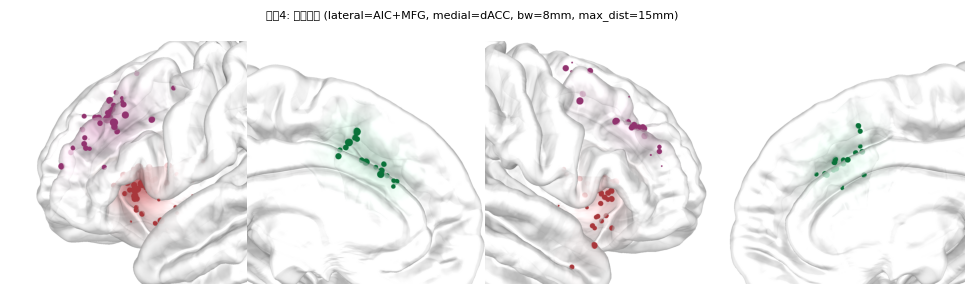

In [10]:
# ============================================================================
# 版本4：聚焦AIC+MFG的密度晕染可视化
# ============================================================================
# 功能：
# 1. lateral视图：相机聚焦在AIC和MFG的中心位置
# 2. medial视图：相机聚焦在dACC的中心位置
# 3. 通过计算电极中心来调整相机焦点
# ============================================================================

from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
from mne.viz import Brain
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import pyvista as pv
from scipy.spatial import cKDTree

def compute_roi_density_with_mask(surface_coords, electrode_coords, hga_values, roi_labels, 
                                   bandwidth=15, max_distance=30):
    """计算每个ROI的HGA加权密度图"""
    unique_rois = np.unique(roi_labels)
    density_by_roi = {}
    mask_by_roi = {}
    
    for roi in unique_rois:
        roi_mask = roi_labels == roi
        roi_coords = electrode_coords[roi_mask]
        roi_hga = hga_values[roi_mask]
        
        if len(roi_coords) > 0:
            distances = cdist(surface_coords, roi_coords)
            min_distances = distances.min(axis=1)
            mask = min_distances < max_distance
            
            kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
            density = np.dot(kernel_values, roi_hga)
            density[~mask] = 0
            
            density_by_roi[roi] = density
            mask_by_roi[roi] = mask
            
            valid_vals = density[mask & (density > 0)]
            if len(valid_vals) > 0:
                print(f"  {roi}: {len(roi_coords)}电极, {mask.sum()}顶点, "
                      f"密度[{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density_by_roi, mask_by_roi


def create_multi_roi_colormap(roi_colors, alpha, n_colors_per_roi=1000):
    """创建多ROI自定义colormap"""
    roi_to_idx = {'MFG': 1, 'AIC': 2, 'dACC': 3}
    colors_list = []
    
    # 0-999: 无数据区域（白色）
    colors_list.extend([[1, 1, 1, 1]] * n_colors_per_roi)
    
    # 为每个ROI创建渐变
    for roi_name in ['MFG', 'AIC', 'dACC']:
        roi_color = np.array(mcolors.to_rgb(roi_colors[roi_name]))
        for i in range(n_colors_per_roi):
            intensity = i / (n_colors_per_roi - 1)
            color = (1 - intensity) * np.array([1, 1, 1]) + intensity * roi_color
            colors_list.append(list(color) + [alpha])
    
    return ListedColormap(colors_list), roi_to_idx


def add_electrodes_to_brain(brain, hemi, coords, hga_vals, roi_vals, color_dict, 
                            surf_tree, surf_coords, vmin, vmax, size_min=5, size_max=35):
    """将电极点添加到Brain对象上"""
    _, indices = surf_tree.query(coords)
    coords_on_pial = surf_coords[indices]
    
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        color = color_dict[roi]
        normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1.0,
        )


def calculate_roi_center(df, roi_list):
    """计算指定ROI的电极中心坐标，过滤异常值"""
    roi_data = df[df['roi'].isin(roi_list)]
    if len(roi_data) > 0:
        # 检查是否有异常值（坐标绝对值过大）
        coords = roi_data[['x', 'y', 'z']].values
        # 过滤掉绝对值超过200的坐标点（正常大脑坐标应该在-100到100之间）
        valid_mask = np.all(np.abs(coords) < 200, axis=1)
        
        if valid_mask.sum() > 0:
            valid_coords = coords[valid_mask]
            center = valid_coords.mean(axis=0)
            
            # 打印诊断信息
            if valid_mask.sum() < len(coords):
                print(f"  警告: {roi_list} 中有 {len(coords) - valid_mask.sum()} 个异常坐标点被过滤")
                invalid_coords = coords[~valid_mask]
                print(f"  异常坐标: {invalid_coords}")
            
            return center
        else:
            print(f"  警告: {roi_list} 所有坐标都是异常值")
            return None
    return None


# ============================================================================
# 主程序
# ============================================================================

# 创建图形
fig, axes = plt.subplots(1, 4, figsize=(32*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1, 1, 1]})
plt.subplots_adjust(wspace=-0.1)

# 参数设置
bandwidth = 8
max_distance = 15
density_alpha = 0.85
cortex_color = (0.9, 0.9, 0.9)
cortex_alpha = 0.01

# ROI颜色定义
roi_colors = {'MFG': '#91336F', 'AIC': red, 'dACC': '#097239'}

# 电极大小映射参数
vmin_hga, vmax_hga = np.percentile(spatial['HGA'].values, 2), np.percentile(spatial['HGA'].values, 98)
size_min, size_max = 10, 50

# 计算AIC+MFG的中心坐标（用于lateral视图）
lh_aic_mfg_center = calculate_roi_center(
    spatial[(spatial['hemi'] == 'L') & (spatial['roi'].isin(['AIC', 'MFG']))],
    ['AIC', 'MFG']
)
rh_aic_mfg_center = calculate_roi_center(
    spatial[(spatial['hemi'] == 'R') & (spatial['roi'].isin(['AIC', 'MFG']))],
    ['AIC', 'MFG']
)

# 计算dACC的中心坐标（用于medial视图）
lh_dacc_center = calculate_roi_center(
    spatial[(spatial['hemi'] == 'L') & (spatial['roi'] == 'dACC')],
    ['dACC']
)
rh_dacc_center = calculate_roi_center(
    spatial[(spatial['hemi'] == 'R') & (spatial['roi'] == 'dACC')],
    ['dACC']
)

print(f"左半球 AIC+MFG 中心: {lh_aic_mfg_center}")
print(f"右半球 AIC+MFG 中心: {rh_aic_mfg_center}")
print(f"左半球 dACC 中心: {lh_dacc_center}")
print(f"右半球 dACC 中心: {rh_dacc_center}")

# 视图配置
view_configs = [
    ('lh', 'lateral', lh_coords_pial, lh_tree, spatial[(spatial['hemi'] == 'L') & (spatial['roi'].isin(['AIC', 'MFG']))], lh_aic_mfg_center),
    ('lh', 'medial', lh_coords_pial, lh_tree, spatial[(spatial['hemi'] == 'L') & (spatial['roi'] == 'dACC')], lh_dacc_center),
    ('rh', 'lateral', rh_coords_pial, rh_tree, spatial[(spatial['hemi'] == 'R') & (spatial['roi'].isin(['AIC', 'MFG']))], rh_aic_mfg_center),
    ('rh', 'medial', rh_coords_pial, rh_tree, spatial[(spatial['hemi'] == 'R') & (spatial['roi'] == 'dACC')], rh_dacc_center),
]

# ========== 第一遍：计算密度并收集全局范围 ==========
all_roi_densities = []
all_global_values = []

for idx, (hemi, view, surf_coords, surf_tree, df_sub, _) in enumerate(view_configs):
    print(f"\n处理 {hemi} {view}:")
    
    if len(df_sub) > 0:
        electrode_coords = df_sub[['x', 'y', 'z']].values
        hga_values = df_sub['HGA'].values
        roi_labels = df_sub['roi'].values
        
        # 过滤异常坐标
        valid_mask = np.all(np.abs(electrode_coords) < 200, axis=1)
        if valid_mask.sum() < len(electrode_coords):
            print(f"  过滤了 {len(electrode_coords) - valid_mask.sum()} 个异常电极")
        
        electrode_coords = electrode_coords[valid_mask]
        hga_values = hga_values[valid_mask]
        roi_labels = roi_labels[valid_mask]
        
        if len(electrode_coords) > 0:
            density_by_roi, mask_by_roi = compute_roi_density_with_mask(
                surf_coords, electrode_coords, hga_values, roi_labels,
                bandwidth=bandwidth, max_distance=max_distance
            )
            
            all_roi_densities.append((density_by_roi, mask_by_roi))
            
            for roi, density in density_by_roi.items():
                mask = mask_by_roi[roi]
                valid_vals = density[mask & (density > 0)]
                if len(valid_vals) > 0:
                    all_global_values.extend(valid_vals)
        else:
            all_roi_densities.append(None)
    else:
        all_roi_densities.append(None)

# 计算全局密度范围
global_vmin = np.min(all_global_values) if all_global_values else 0
global_vmax = np.max(all_global_values) if all_global_values else 1
print(f"\n全局密度范围: [{global_vmin:.4f}, {global_vmax:.4f}]")

# 创建自定义colormap
custom_cmap, roi_to_idx = create_multi_roi_colormap(roi_colors, density_alpha)

# ========== 第二遍：绘制密度 + 电极叠加 ==========
for idx, (hemi, view, surf_coords, surf_tree, df_sub, focal_point) in enumerate(view_configs):
    ax = axes[idx]
    
    # 初始化Brain对象
    brain = Brain('fsaverage', subjects_dir=recon_dir, surf='pial', hemi=hemi,
                  background='white', show=False, cortex=cortex_color, 
                  alpha=cortex_alpha, size=(600*cm, 600*cm))
    brain._renderer.plotter.window_size = [1400, 1400]
    brain._renderer.plotter.set_background('white')

    # 第1层：添加密度晕染
    if all_roi_densities[idx] is not None:
        density_by_roi, mask_by_roi = all_roi_densities[idx]
        n_vertices = len(surf_coords)
        
        # Winner-takes-all策略
        combined_density = np.zeros(n_vertices)
        roi_assignment = np.zeros(n_vertices, dtype=int)
        
        for roi, density in density_by_roi.items():
            mask = mask_by_roi[roi]
            update_mask = (density > combined_density) & mask & (density > 0)
            combined_density[update_mask] = density[update_mask]
            roi_assignment[update_mask] = roi_to_idx[roi]
        
        # 编码数据
        data_to_plot = np.zeros(n_vertices)
        has_roi = roi_assignment > 0
        if has_roi.any():
            norm_density = np.clip((combined_density[has_roi] - global_vmin) / (global_vmax - global_vmin), 0, 1)
            data_to_plot[has_roi] = roi_assignment[has_roi] * 1000 + norm_density * 999
        
        # 添加密度数据
        brain.add_data(data_to_plot, hemi=hemi, colormap=custom_cmap, 
                      alpha=density_alpha, colorbar=False, fmin=0, fmax=4000)
        
        print(f"  密度层: MFG={(roi_assignment == 1).sum()}, "
              f"AIC={(roi_assignment == 2).sum()}, dACC={(roi_assignment == 3).sum()}顶点")
    
    # 第2层：添加电极点（过滤异常坐标）
    if len(df_sub) > 0:
        coords = df_sub[['x', 'y', 'z']].values
        valid_mask = np.all(np.abs(coords) < 200, axis=1)
        
        if valid_mask.sum() > 0:
            add_electrodes_to_brain(
                brain, hemi, 
                coords[valid_mask],
                df_sub['HGA'].values[valid_mask],
                df_sub['roi'].values[valid_mask],
                roi_colors,
                surf_tree, surf_coords,
                vmin_hga, vmax_hga,
                size_min, size_max
            )
            print(f"  电极层: {valid_mask.sum()}个电极")
    
    # 设置视图：根据view类型和focal_point设置相机
    if focal_point is not None:
        brain.show_view(view=view, distance=250)
        # 设置相机焦点到ROI中心
        brain._renderer.plotter.camera.focal_point = focal_point
        
        if view == 'lateral':
            # lateral视图：相机在左右侧
            brain._renderer.plotter.camera.position = (
                focal_point[0] - 200 if hemi == 'lh' else focal_point[0] + 200,
                focal_point[1],
                focal_point[2]
            )
        else:  # medial视图
            # medial视图：相机在内侧
            brain._renderer.plotter.camera.position = (
                focal_point[0] + 200 if hemi == 'lh' else focal_point[0] - 200,
                focal_point[1],
                focal_point[2]
            )
    else:
        brain.show_view(view=view, distance=380)
    
    ax.imshow(brain.screenshot(mode='rgb'))
    ax.axis('off')
    brain.close()

plt.suptitle(f'版本4: 聚焦视图 (lateral=AIC+MFG, medial=dACC, bw={bandwidth}mm, max_dist={max_distance}mm)', fontsize=8)

print(f"\n✓ 版本4完成！")
print(f"说明：lateral视图聚焦在AIC和MFG区域，medial视图聚焦在dACC区域")
print(f"     背景=HGA加权密度晕染（AIC=红, MFG=蓝, dACC=绿）")
print(f"     前景=电极点（颜色=ROI，大小=HGA强度）")

plt.savefig('../img/misc/AMN_spatial.svg', dpi=300, bbox_inches='tight')

# Temporal dynamics

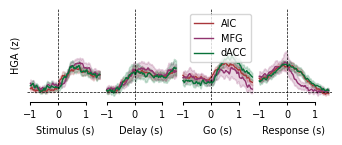

In [13]:
rois = ['AIC', 'MFG','dACC']

colors = [red, '#91336F', '#097239']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    # & (HGAs.hemi=='L')
    & (HGAs.subject!='D0007')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject!='D0121')
]

phases = ['stimulus', 'delay', 'go' ,'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, 3*cm),)

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (ax, phase) in zip(axes, phases):
    
    legend = True if ax == axes[-2] else False
    line1 = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend,
        lw=1
    )
    
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
    if ax != axes[0]:
        # ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('', fontsize=7)
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

plt.savefig('../img/misc/AMN_temporal.svg', dpi=300, bbox_inches='tight')
plt.show()

## Task modulation and lexicality


### Dec & Repeat

In [123]:
# ── Load Decision vs Repeat univariate contrast results (BIDSPath style) ──
ref = 'bipolar'
contrast_paths = []
for t in ['LexicalDelay']:
    contrast_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='univariate',
            description='DecisionVsRepeat',
            suffix='highgamma',
            check=False,
        ).match()
    )

print(f"Found {len(contrast_paths)} contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)
    df['subject'] = path.subject
    df['task'] = path.task
    contrast_dfs.append(df)

dec_vs_rep = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info from HGAs (channel + subject is unique key)
# Get unique channel metadata from HGAs
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
dec_vs_rep = dec_vs_rep.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
dec_vs_rep = dec_vs_rep[~dec_vs_rep.channel.isin(exclude_chn)]

print(f"Total: {len(dec_vs_rep)} rows, {dec_vs_rep.subject.nunique()} subjects")
print(f"ROIs: {sorted(dec_vs_rep.roi.dropna().unique())}")


# take only the channel in HGAs
pick_chn = HGAs.channel.unique()
# dec_vs_rep = dec_vs_rep[dec_vs_rep.channel.isin(pick_chn)]
dec_vs_rep.head()

Found 44 contrast files


100%|██████████| 44/44 [00:01<00:00, 30.27it/s]


Total: 2141440 rows, 44 subjects
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'LatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'dACC', 'iOccGs', 'mOccG']


,channel,time,mask,p,mean_a,mean_b,mean_diff,significant,direction,phase,subject,task,roi,hemi,label,x,y,z
0,D0023_R1MF1-2,-1.000000,0,0.122775,-0.171255,0.007724,-0.178979,False,NaN,delay,D0023,LexicalDelay,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
1,D0023_R1MF1-2,-0.992188,0,0.249150,-0.126926,0.009165,-0.136090,False,NaN,delay,D0023,LexicalDelay,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
2,D0023_R1MF1-2,-0.984375,0,0.484303,-0.070231,0.013564,-0.083794,False,NaN,delay,D0023,LexicalDelay,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
3,D0023_R1MF1-2,-0.976562,0,0.687463,-0.023845,0.024836,-0.048681,False,NaN,delay,D0023,LexicalDelay,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
4,D0023_R1MF1-2,-0.968750,0,0.784643,0.004692,0.035745,-0.031053,False,NaN,delay,D0023,LexicalDelay,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046


## Lexicality

In [126]:
ref = 'bipolar'
contrast_paths = []
for t in ['LexicalDelay']:
    contrast_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='univariate',
            # description='WordVsNonwordDecision',
            suffix='highgamma',
            check=False,
        ).match()
    )

print(f"Found {len(contrast_paths)} contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)
    df['subject'] = path.subject
    df['task'] = path.task
    df['description'] = path.description
    contrast_dfs.append(df)

lexicality = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info from HGAs (channel + subject is unique key)
# Get unique channel metadata from HGAs
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
lexicality = lexicality.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
lexicality = lexicality[~lexicality.channel.isin(exclude_chn)]

print(f"Total: {len(lexicality)} rows, {lexicality.subject.nunique()} subjects")
print(f"ROIs: {sorted(lexicality.roi.dropna().unique())}")


# take only the channel in HGAs
pick_chn = HGAs.channel.unique()
lexicality = lexicality[lexicality.channel.isin(pick_chn)]
lexicality = lexicality[lexicality.description != 'DecisionVsRepeat']

# --- remove electrodes with pre-0 significance in stimulus ---
pre0_bad = lexicality[
    (lexicality['phase'] == 'stimulus') &
    (lexicality['time'] < 0) &
    (lexicality['significant'] == True) &
    (lexicality['mask'] == True)
]['channel'].unique()

print(f"Channels with pre-0 significant activity in stimulus: {len(pre0_bad)}")

# 全局删除这些电极（所有 phase / condition 都删）
lexicality = lexicality[~lexicality['channel'].isin(pre0_bad)].copy()

print(f"Remaining channels: {lexicality['channel'].nunique()}")

# map description
lexicality['description'] = lexicality['description'].map({
    'WordVsNonwordDecision': 'Decision',
    'WordVsNonwordRepeat': 'Repeat',
})
lexicality.head()

Found 132 contrast files


 23%|██▎       | 31/132 [00:00<00:02, 48.89it/s]/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3238269/900892672.py:18: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
100%|██████████| 132/132 [00:04<00:00, 32.88it/s]


Total: 6424320 rows, 44 subjects
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'LatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'dACC', 'iOccGs', 'mOccG']
Channels with pre-0 significant activity in stimulus: 44
Remaining channels: 1020


,channel,time,mask,p,mean_a,mean_b,mean_diff,significant,direction,phase,subject,task,description,roi,hemi,label,x,y,z
44800,D0023_R1MF1-2,-1.000000,0,0.352729,-0.241366,-0.095912,-0.145454,False,NaN,delay,D0023,LexicalDelay,Decision,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
44801,D0023_R1MF1-2,-0.992188,0,0.234353,-0.217678,-0.029401,-0.188277,False,NaN,delay,D0023,LexicalDelay,Decision,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
44802,D0023_R1MF1-2,-0.984375,0,0.255149,-0.163942,0.030474,-0.194416,False,NaN,delay,D0023,LexicalDelay,Decision,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
44803,D0023_R1MF1-2,-0.976562,0,0.303939,-0.111898,0.070779,-0.182677,False,NaN,delay,D0023,LexicalDelay,Decision,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046
44804,D0023_R1MF1-2,-0.968750,0,0.387123,-0.073584,0.088809,-0.162394,False,NaN,delay,D0023,LexicalDelay,Decision,dACC,R,ctx_rh_G_and_S_cingul-Mid-Ant,9.295536,5.962643,32.639046


In [ ]:
rois = ['AIC', 'MFG', 'dACC']
dec_vs_rep = dec_vs_rep[dec_vs_rep.roi.isin(rois)]
lexicality = lexicality[lexicality.roi.isin(rois)]
